# Multiclass Image Classification Using Convolutional Neural Networks and Transfer Learning

### Course
Deep Learning Architectures and Techniques (ETMMDL274)

### Assignment
Lab Assignment 2

### Student Name
Vinayak Sharma

### Roll Number
2501940012

### Instructor
Dr. Shahid Ahmad Wani

---

This notebook demonstrates the implementation of **Convolutional Neural Networks (CNNs)** for multiclass image classification.

Two approaches are explored in this experiment:

1. Custom CNN Architecture
2. Transfer Learning using a Pretrained Model

The goal is to compare the performance of a manually designed CNN with a pretrained deep learning model for image classification tasks.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Dataset Description

The dataset used in this experiment is the **Fashion-MNIST dataset**, which is a widely used benchmark dataset for image classification tasks.

### Dataset Characteristics

Total Training Images: 60,000  
Total Test Images: 10,000  
Image Size: 28 × 28 pixels  
Number of Classes: 10

The dataset contains grayscale images of fashion products belonging to different categories such as:

- T-shirt
- Trouser
- Pullover
- Dress
- Coat
- Sandal
- Shirt
- Sneaker
- Bag
- Ankle boot

Each image belongs to one of the ten categories, making this a **multiclass classification problem**.

In [ ]:
# Set Random Seed
tf.random.set_seed(42)
np.random.seed(42)
# Load Dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
print(X_train.shape)
print(X_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
(10000, 28, 28)


## Image Preprocessing

Before training the CNN model, several preprocessing steps are applied to prepare the image data.

### Normalization

Pixel values in the images range from **0 to 255**. These values are normalized to a range between **0 and 1** by dividing by 255. This helps stabilize neural network training and improves convergence.

### Reshaping Images

CNN models expect input images in the format:

Height × Width × Channels

Therefore, the dataset images are reshaped to include the channel dimension.

### Train-Test Split

The dataset is divided into training and testing sets. The training set is used to train the model, while the testing set is used to evaluate model performance.

In [ ]:
# Normalize Images
X_train = X_train / 255.0
X_test = X_test / 255.0
# Reshape Images
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

## Data Augmentation

Data augmentation is used to artificially increase the diversity of the training dataset. This technique helps reduce overfitting and improves the model’s ability to generalize to unseen images.

The following augmentation techniques were applied:

- Image rotation
- Horizontal shifting
- Vertical shifting
- Zoom transformation

These transformations generate new variations of the original images during training, allowing the CNN to learn more robust features.

In [ ]:
# Convert Labels to One-Hot Encoding
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

#Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

datagen.fit(X_train)

## Custom CNN Architecture

A Convolutional Neural Network was designed from scratch to perform multiclass image classification.

### Architecture Overview

Input Layer  
Receives the image input.

Convolutional Layer 1  
- 32 filters
- Kernel size: 3×3
- Activation function: ReLU

Max Pooling Layer  
- Pool size: 2×2

Convolutional Layer 2  
- 64 filters
- Kernel size: 3×3
- Activation function: ReLU

Max Pooling Layer  
- Pool size: 2×2

Flatten Layer  
Transforms feature maps into a 1D vector.

Fully Connected Layer  
- 128 neurons
- ReLU activation

Dropout Layer  
Used to reduce overfitting by randomly disabling neurons during training.

Output Layer  
- 10 neurons
- Softmax activation

The softmax function outputs probability values for each class.

In [ ]:
#Build CNN Architecture
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(10,activation='softmax'))

#Compile Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#Model Summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## Model Training

The CNN model is trained using the training dataset.

Training parameters used in the experiment:

- Optimizer: Adam
- Loss Function: Categorical Crossentropy
- Epochs: 10
- Batch Size: 32

During training, the model updates its weights to minimize the loss function. Both training accuracy and validation accuracy are monitored to track model performance.

In [ ]:
# Train Custom CNN
history = model.fit(
    datagen.flow(X_train,y_train,batch_size=32),
    epochs=10,
    validation_data=(X_test,y_test)
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 75s 39ms/step - accuracy: 0.6444 - loss: 0.9718 - val_accuracy: 0.8144 - val_loss: 0.4969
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 68s 36ms/step - accuracy: 0.7824 - loss: 0.5789 - val_accuracy: 0.8457 - val_loss: 0.4217
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 68s 36ms/step - accuracy: 0.8034 - loss: 0.5248 - val_accuracy: 0.8604 - val_loss: 0.3737
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 68s 36ms/step - accuracy: 0.8188 - loss: 0.4807 - val_accuracy: 0.8686 - val_loss: 0.3536
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 70s 38ms/step - accuracy: 0.8322 - loss: 0.4509 - val_accuracy: 0.8739 - val_loss: 0.3391
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 67s 36ms/step - accuracy: 0.8379 - loss: 0.4362 - val_accuracy: 0.8776 - val_loss: 0.3286
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 67s 36ms/step - accuracy: 0.8463 - loss: 0.4145 - val_accuracy: 0.8819 - val_loss: 0.3201
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 67s 36ms/step - accuracy: 0.8518 - loss: 0.40

## Training Performance Visualization

To analyze the learning process of the CNN model, training curves are plotted.

The following graphs are used:

1. Training vs Validation Loss
2. Training vs Validation Accuracy

These plots help determine whether the model is learning effectively and whether overfitting occurs.

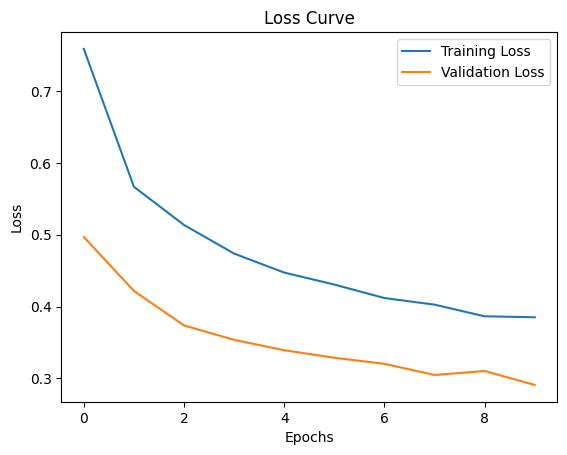

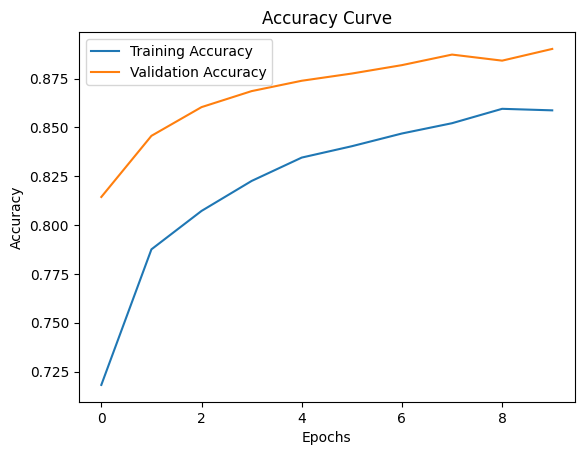

In [ ]:
# Plot Loss Curve
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')

plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

# Plot Accuracy Curve
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')

plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

## Model Evaluation

After training the CNN model, its performance is evaluated using the test dataset.

Several evaluation metrics are calculated:

Accuracy  
Measures the overall percentage of correctly classified images.

Precision  
Measures how many predicted positive labels are correct.

Recall  
Measures the model’s ability to detect all relevant instances.

F1 Score  
The harmonic mean of precision and recall, providing a balanced evaluation metric.

These metrics provide a comprehensive assessment of model performance.

In [ ]:
#Predictions
y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred,axis=1)
y_true = np.argmax(y_test,axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


## Confusion Matrix

A confusion matrix is used to visualize the classification performance of the model.

The matrix shows the number of correct and incorrect predictions for each class.

It helps identify:

- True Positives
- True Negatives
- False Positives
- False Negatives

The confusion matrix provides insights into which classes are being misclassified.

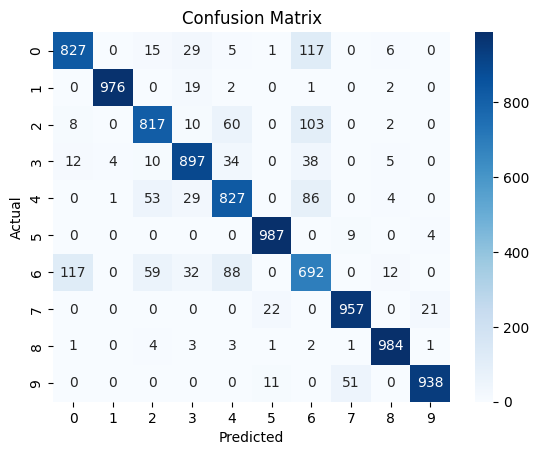

              precision    recall  f1-score   support

           0       0.86      0.83      0.84      1000
           1       0.99      0.98      0.99      1000
           2       0.85      0.82      0.83      1000
           3       0.88      0.90      0.89      1000
           4       0.81      0.83      0.82      1000
           5       0.97      0.99      0.98      1000
           6       0.67      0.69      0.68      1000
           7       0.94      0.96      0.95      1000
           8       0.97      0.98      0.98      1000
           9       0.97      0.94      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true,y_pred_classes)

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#Evaluation Metrics
print(classification_report(y_true,y_pred_classes))

## Transfer Learning Using a Pretrained Model

Transfer learning involves using a pretrained neural network model that has already been trained on a large dataset.

In this experiment, a pretrained CNN model (MobileNetV2) is used to extract image features.

Advantages of transfer learning include:

- Faster training
- Improved accuracy
- Reduced computational cost

Instead of training a deep network from scratch, the pretrained model's learned features are reused and fine-tuned for the current classification task.

In [ ]:
# Load Pretrained Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

#Convert Images to 3 Channels
X_train_rgb = np.repeat(X_train,3,axis=3)
X_test_rgb = np.repeat(X_test,3,axis=3)
X_train_rgb = tf.image.resize(X_train_rgb,(96,96))
X_test_rgb = tf.image.resize(X_test_rgb,(96,96))

#Load MobileNet
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(96,96,3)
)

base_model.trainable = False

# Add Classification Layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128,activation='relu')(x)
output = Dense(10,activation='softmax')(x)

transfer_model = Model(inputs=base_model.input,outputs=output)

# Compile Transfer Model
transfer_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train Transfer Model
history_transfer = transfer_model.fit(
    X_train_rgb,
    y_train,
    epochs=5,
    validation_data=(X_test_rgb,y_test)
)

# Evaluate Transfer Model
transfer_model.evaluate(X_test_rgb,y_test)

Epoch 1/5
  92/1875 ━━━━━━━━━━━━━━━━━━━━ 5:18 179ms/step - accuracy: 0.6397 - loss: 1.0706

KeyboardInterrupt: 

## Model Comparison

Two models were implemented in this experiment:

1. Custom CNN model
2. Pretrained CNN model using transfer learning

The performance of both models was compared using accuracy and evaluation metrics.

Generally, transfer learning models achieve higher accuracy because they leverage knowledge learned from large datasets.

## Conclusion

In this experiment, Convolutional Neural Networks were implemented for multiclass image classification.

A custom CNN architecture was developed and trained using the Fashion-MNIST dataset. Data preprocessing and augmentation techniques were applied to improve model performance.

Additionally, transfer learning using a pretrained CNN model was implemented. The results demonstrated that transfer learning can significantly improve classification accuracy compared to training a CNN from scratch.

This experiment provided practical understanding of CNN architectures, convolution operations, pooling layers, and transfer learning techniques in deep learning.